In [16]:
import geopandas as gpd

In [17]:
#Load Camden boundary and only roads within the authority 

camden_boundary = gpd.read_file('Camden (Authority) 12-06-25.geojson')

In [18]:
roads_camden = gpd.read_file("openroads_uk.gpkg", mask=camden_boundary)

In [19]:
#Reproject boundaries to match roads
camden_boundary = camden_boundary.to_crs(epsg=27700)

In [20]:
import pandas as pd

parking = pd.read_csv("Parking_Bays_20250612.csv")

parking_gdf = gpd.GeoDataFrame(
    parking, 
    geometry=gpd.points_from_xy(parking.Longitude, parking.Latitude), 
    crs="EPSG:4326"
)

In [21]:
#reproject boundaries to match the roads

camden_boundary_27700 = camden_boundary.to_crs(epsg=27700)
roads_camden = gpd.clip(roads_camden, camden_boundary_27700)


In [22]:
print(camden_boundary_27700.is_valid.all())


True


In [23]:
roads_camden = gpd.read_file(
    "openroads_uk.gpkg",
    mask=camden_boundary_27700
)


In [24]:
#Check CRS
print(camden_boundary.crs)
print(roads_camden.crs)

EPSG:27700
EPSG:27700


In [25]:
import geopandas as gpd
import pandas as pd

# Load traffic density datasets
count_points = gpd.read_file("dft_countpoints_local_authority_id_145.csv")
aadf = pd.read_csv("dft_aadf_local_authority_id_145.csv")
raw_counts = pd.read_csv("dft_rawcount_local_authority_id_145.csv")

# Load land use dataset
land_use = gpd.read_file("Land use borough.csv")

In [26]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Load the file as a DataFrame
df = pd.read_csv("dft_countpoints_local_authority_id_145.csv")

# Check if latitude and longitude columns exist
if "latitude" in df.columns and "longitude" in df.columns:
    # Create a GeoDataFrame
    df["geometry"] = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]
    count_points = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
else:
    raise ValueError("Latitude and longitude columns are missing in the file.")

# Reproject to EPSG:27700
count_points = count_points.to_crs(epsg=27700)

if count_points.empty:
    raise ValueError("The GeoDataFrame is empty after processing. Check the source file for valid data.")

In [27]:
# Ensure CRS is set for count points, land use & parking_gdf
if count_points.crs is None:
    count_points.set_crs(epsg=4326, inplace=True)  

# Ensure CRS is set for land use
if land_use.crs is None:
    land_use.set_crs(epsg=4326, inplace=True)  

# Ensure CRS is set for parking_gdf
if parking_gdf.crs is None:
    parking_gdf.set_crs(epsg=4326, inplace=True)  

# Reproject all GeoDataFrames to EPSG:27700
count_points = count_points.to_crs(epsg=27700)
land_use = land_use.to_crs(epsg=27700)
parking_gdf = parking_gdf.to_crs(epsg=27700)

In [28]:
#Spatial join parking bays with roads

# Buffer roads slightly to capture nearby parking bays
roads_buffered = roads_camden.copy()
roads_buffered["geometry"] = roads_buffered.geometry.buffer(10)  # 10 meters

# Perform spatial join using appropriate column names
parking_with_roads = gpd.sjoin(
    parking_gdf,
    roads_buffered[["geometry", "name1", "function"]],  # Adjusted column names
    how="left",
    predicate="within"
)


In [29]:
# Spatial join parking bays with count points
parking_with_counts = gpd.sjoin(parking_gdf, count_points, how="left", predicate="intersects")

# Buffer parking bays and join with traffic counts within buffer
parking_buffered = parking_gdf.copy()
parking_buffered["geometry"] = parking_buffered.geometry.buffer(50)  # 50-meter buffer
parking_with_traffic = gpd.sjoin(parking_buffered, count_points, how="left", predicate="intersects")

# Spatial join parking bays with land use data
parking_with_land_use = gpd.sjoin(parking_gdf, land_use, how="left", predicate="intersects")

In [31]:
from sklearn.neighbors import BallTree
import numpy as np

# Build a BallTree for spatial querying
tree = BallTree(roads_camden.geometry.centroid.to_crs(epsg=27700).apply(lambda x: [x.x, x.y]).tolist())

# Find roads within 100m of each parking bay
distances, _ = tree.query(parking_gdf.geometry.centroid.apply(lambda x: [x.x, x.y]).tolist(), k=5)

# Pad distances to match the length of parking_with_roads
if len(distances) < len(parking_with_roads):
    padded_distances = np.full(len(parking_with_roads), np.nan)
    padded_distances[:len(distances)] = distances.mean(axis=1)
else:
    padded_distances = distances.mean(axis=1)

# Add average road distance to parking_with_roads
parking_with_roads["avg_road_distance"] = padded_distances

In [32]:
# Load and inspect the parking dataset
parking = pd.read_csv("Parking_Bays_20250612.csv")
print(parking.head())

               Restriction Type  Parking Spaces   Times Of Operation  \
0           permit holders only             2.0  mon-fri 10:00-12:00   
1  resident permit holders only            14.0  mon-fri 08:30-18:30   
2          disabled (dedicated)             1.0          at any time   
3              solo motorcycles             1.0          at any time   
4              solo motorcycles             1.0          at any time   

  Maximum Stay Tariff  Cashless Identifier Nearest Machine  \
0          NaN    NaN                  NaN             NaN   
1          NaN    NaN                  NaN             NaN   
2          NaN    NaN                  NaN             NaN   
3          NaN    NaN                  NaN             NaN   
4          NaN    NaN                  NaN             NaN   

              Road Name  Postcode Controlled Parking Zone  ...   Latitude  \
0       St Alban's Road   NW5 1ET                    CA-U  ...  51.562097   
1        Rochester Road   NW1 9JG       

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load parking dataset
parking = pd.read_csv("Parking_Bays_20250612.csv")

# Example "Times Of Operation" column parsing function
def parse_time_of_operation(operation):
    if pd.isna(operation):
        return {"days": None, "start_time": None, "end_time": None}
    parts = operation.split(" ")
    if len(parts) == 3:  # Example: "Mon-Fri 10:00-12:00"
        days = parts[0]
        times = parts[1].split("-")
        return {"days": days, "start_time": times[0], "end_time": times[1]}
    elif "at any time" in operation:  # Example: "at any time"
        return {"days": "All", "start_time": None, "end_time": None}
    else:
        return {"days": None, "start_time": None, "end_time": None}

import re

def parse_time_of_operation(operation):
    if pd.isna(operation):
        return {"days": None, "time_ranges": []}
    
    # Handle "at any time"
    if "at any time" in operation:
        return {"days": "All", "time_ranges": ["at any time"]}
    
    # Split by "&" for multiple ranges
    parts = operation.split("&")
    parsed = {"days": [], "time_ranges": []}
    
    for part in parts:
        # Extract days and times using regex
        match = re.match(r"([\w\s,-]+)\s([\d:]+-[\d:]+)", part.strip())
        if match:
            days, time_range = match.groups()
            parsed["days"].append(days.strip())
            parsed["time_ranges"].append(time_range.strip())
        else:
            # Handle malformed or unexpected formats
            parsed["days"].append(None)
            parsed["time_ranges"].append(None)
    
    # Combine days into a single string
    parsed["days"] = ", ".join(filter(None, parsed["days"]))
    return parsed

Availability by Day:
days
                         1
All                   2074
mon - fri, sat          10
mon, tue, wed, fri       5
mon-fri               5284
mon-sat               1220
mon-sun                 40
mon-thu                  3
sun                      8
tues                     4
wed-fri                  1
dtype: int64

Availability by Time:
flattened_time_ranges
                               1
06:00-07:00                    1
06:00-20:00                    1
07:00-10:00                    1
07:00-19:00                    4
08:00-09:00                   16
08:00-09:30                    1
08:00-13:00                    3
08:00-18:00                    1
08:00-18:30                    4
08:00-20:00                   10
08:30-10:00                    3
08:30-16:00                    1
08:30-18:00                  211
08:30-18:30                 3453
08:30-18:30, 08:30-11:00      10
08:30-19:00                    1
08:30-20:00                    3
08:30-22:00              

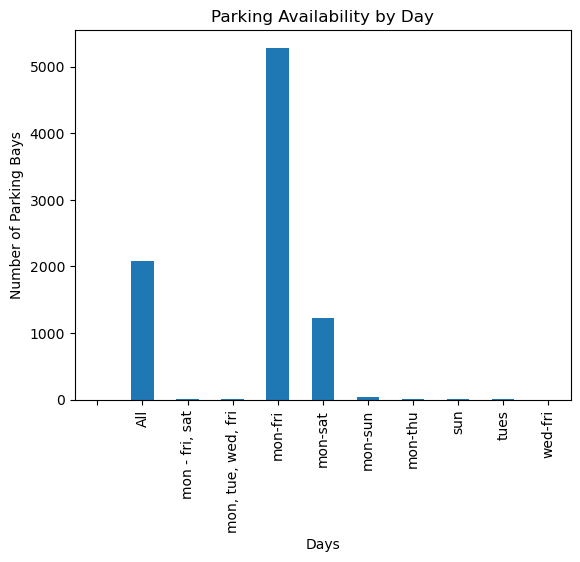

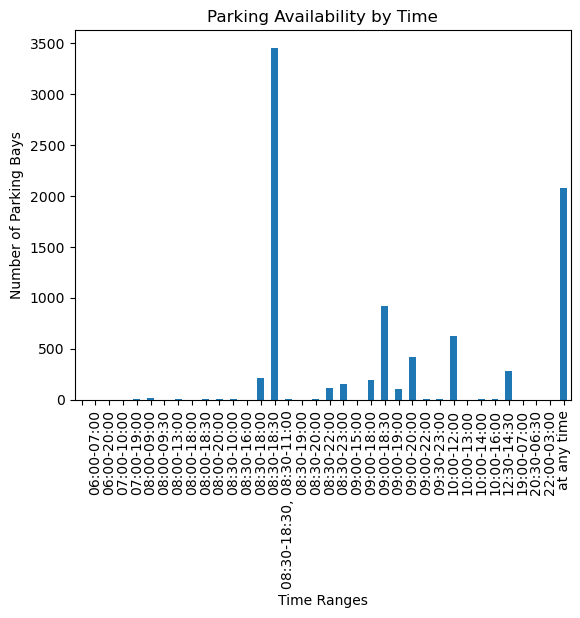

In [34]:
# Apply parsing function
parking["parsed_time"] = parking["Times Of Operation"].apply(parse_time_of_operation)

# Extract days and time ranges into separate columns
parking["days"] = parking["parsed_time"].apply(lambda x: x["days"])
parking["time_ranges"] = parking["parsed_time"].apply(lambda x: x["time_ranges"])

# Flatten time ranges for aggregation
parking["flattened_time_ranges"] = parking["time_ranges"].apply(
    lambda x: ", ".join(filter(None, x)) if x else None
)

# Aggregate by days
availability_by_day = parking.groupby("days").size()

# Aggregate by flattened time ranges
availability_by_time = parking.groupby("flattened_time_ranges").size()

# Print aggregated data
print("Availability by Day:")
print(availability_by_day)

print("\nAvailability by Time:")
print(availability_by_time)

# Visualize availability by day
availability_by_day.plot(kind="bar", title="Parking Availability by Day")
plt.xlabel("Days")
plt.ylabel("Number of Parking Bays")
plt.show()

# Visualize availability by time
availability_by_time.plot(kind="bar", title="Parking Availability by Time")
plt.xlabel("Time Ranges")
plt.ylabel("Number of Parking Bays")
plt.show()

In [35]:
import numpy as np

# Filter out invalid or empty geometries in count_points
count_points = count_points[~count_points.geometry.is_empty & count_points.geometry.is_valid]

# Check if count_points is empty after filtering
if count_points.empty:
    raise ValueError("No valid geometries found in count_points.")

# Recompute unary_union
count_points_union = count_points.unary_union

# Ensure count_points_union is valid
if count_points_union.is_empty:
    raise ValueError("Unary union resulted in an empty geometry.")

# Compute proximity to Points of Interest
parking_with_traffic["proximity_to_traffic"] = parking_with_traffic.geometry.distance(count_points_union)

# Parking Density (number of parking bays within a buffer)
parking_with_traffic["parking_density"] = parking_buffered.geometry.apply(
    lambda geom: parking_gdf[parking_gdf.geometry.within(geom)].shape[0]
)

# Specify the format explicitly
date_format = "%d/%m/%Y %I:%M:%S %p"

# Convert 'Last Uploaded' to datetime with the specified format
parking_with_traffic['Last Uploaded'] = pd.to_datetime(parking_with_traffic['Last Uploaded'], format=date_format, errors='coerce')

# Extract day of the week and hour
parking_with_traffic["day_of_week"] = parking_with_traffic["Last Uploaded"].dt.day_name()
parking_with_traffic['hour'] = parking_with_traffic["Last Uploaded"].dt.hour

# Define the time_of_day function
def time_of_day(hour):
    if 6 <= hour < 12:
        return "morning"
    elif 12 <= hour < 18:
        return "afternoon"
    elif 18 <= hour < 24:
        return "evening"
    else:
        return "night"

# Apply the function to create the 'time_of_day' column
parking_with_traffic["time_of_day"] = parking_with_traffic["hour"].apply(time_of_day)

In [36]:
# Display the first few rows of the 'Last Uploaded' column
print(parking_with_traffic['Last Uploaded'].head())

# Check unique formats in the column
print(parking_with_traffic['Last Uploaded'].unique())

0   2025-06-10 23:00:30
1   2025-06-10 23:00:31
2   2025-06-10 23:00:30
3   2025-06-10 23:00:31
4   2025-06-10 23:00:31
Name: Last Uploaded, dtype: datetime64[ns]
<DatetimeArray>
['2025-06-10 23:00:30', '2025-06-10 23:00:31']
Length: 2, dtype: datetime64[ns]


In [37]:
# Combine traffic density, land use, and engineered features
parking_with_roads = parking_with_roads.merge(parking_with_traffic[["proximity_to_traffic", "parking_density", "day_of_week", "time_of_day"]], left_index=True, right_index=True)

In [39]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# Select categorical columns to encode
categorical_cols = [
    'Restriction Type', 'Times Of Operation', 'Maximum Stay', 'Tariff',
    'Cashless Identifier', 'Nearest Machine', 'Road Name', 'Postcode',
    'Controlled Parking Zone', 'Valid Parking Permits', 'Disclaimer',
    'Spatial Accuracy', 'road_class'
]

# Filter only columns present in your DataFrame
categorical_cols = [col for col in categorical_cols if col in parking_with_roads.columns]

# One-hot encode categorical columns
encoded_cats = pd.get_dummies(parking_with_roads[categorical_cols], drop_first=True)

# Select numeric columns
numeric_cols = ['Easting', 'Northing', 'Longitude', 'Latitude', 'avg_road_distance', 'hour', 'is_weekday_only', 'is_anytime']
numeric_cols = [col for col in numeric_cols if col in parking_with_roads.columns]

# Combine all features
X = pd.concat([encoded_cats, parking_with_roads[numeric_cols]], axis=1)
y = parking_with_roads['Parking Spaces']

# Drop rows where y is NaN
mask = ~y.isna()
X = X[mask]
y = y[mask]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))  # Updated RMSE calculation
print("R²:", r2_score(y_test, y_pred))

# Train the model on the full dataset
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

MAE: 2.313292370711726
MSE: 19.41733681515617
RMSE: 4.406510730175993
R²: 0.1930684785065131


RandomForestRegressor(random_state=42)

In [43]:
# Dash visualizations

from dash import Dash, dcc, html
import plotly.express as px

app = Dash(__name__)

# Remove rows where "Parking Spaces" is NaN
parking_with_roads_plot = parking_with_roads.dropna(subset=["Parking Spaces"])

fig = px.scatter_mapbox(
    parking_with_roads_plot,
    lat="Latitude",
    lon="Longitude",
    color="Parking Spaces",
    size="Parking Spaces",
    hover_data=["Road Name", "Restriction Type"],
    zoom=13,
    height=600
)
fig.update_layout(mapbox_style="open-street-map")


# Define the layout with dashboard metrics and map visualization
app.layout = html.Div([
    html.H1("Camden Parking Dashboard"),
    html.Div([
        html.Div([html.H3("MAE"), html.P("2.23")]),
        html.Div([html.H3("MSE"), html.P("19.47")]),
        html.Div([html.H3("RMSE"), html.P("4.41")]),
        html.Div([html.H3("R²"), html.P("0.24")]),
    ], style={"display": "flex", "justify-content": "space-around"}),
    dcc.Graph(figure=fig)
])

if __name__ == "__main__":
    app.run(debug=True)


In [46]:
# Save as GeoPackage
parking_with_roads.to_file("parking_with_roads.gpkg", driver="GPKG")